
---

# ⏳ **Early Stopping in Neural Networks**  
*A simple trick to prevent overfitting and save training time!*

---

## ✅ **What is Early Stopping?**

📌 **Early Stopping** is a **regularization technique** used during training to **stop training once the model stops improving** on a validation dataset.

> 💡 It prevents the model from **overfitting** to the training data and helps keep it **generalizable**.

---

### 🧠 Intuition:

- During training, your model's **training loss** keeps decreasing.
- But your **validation loss** will **first decrease**, then start **increasing** when overfitting starts.
- Early stopping **monitors the validation loss**, and **stops training** once it stops improving.

---

### 📈 Example Scenario:

```
Epoch 1 → val_loss = 0.45
Epoch 2 → val_loss = 0.38 ✅
Epoch 3 → val_loss = 0.36 ✅
Epoch 4 → val_loss = 0.39 ❌ (starts increasing)
Epoch 5 → val_loss = 0.41 ❌
→ EARLY STOPPING TRIGGERS
```

---

## 🔄 **How Does Early Stopping Work?**

1. Split your data into **training** and **validation** sets.
2. Monitor a performance metric (e.g., **validation loss**, **accuracy**).
3. If the metric **stops improving** for a defined number of epochs (called **patience**), stop training.
4. Optionally, **restore the best weights** from the epoch where validation loss was lowest.

---

## 🔢 **Key Parameters**

| Parameter | Description |
|----------|-------------|
| **monitor** | What to monitor (e.g., `'val_loss'`, `'val_accuracy'`) |
| **patience** | Number of epochs to wait before stopping after no improvement |
| **min_delta** | Minimum change to qualify as improvement |
| **restore_best_weights** | Whether to rollback to the best weights |

---

## 💻 Example: Early Stopping in Keras

```python
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build model
model = Sequential([
    Dense(64, activation='relu', input_shape=(10,)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# EarlyStopping Callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=100,
                    callbacks=[early_stop])
```

✅ Training stops early if the validation loss doesn’t improve for 5 epochs.

---

## 🎯 **Benefits of Early Stopping**

| 🔥 Benefit             | ✅ Description |
|------------------------|----------------|
| **Prevents Overfitting** | Stops training before the model memorizes the data |
| **Reduces Training Time** | Saves compute by stopping early |
| **Improves Generalization** | Picks the model that performs best on unseen data |
| **Simple to Implement** | Works with almost every training pipeline |

---

## ❗ When Not to Use

- If you **don't have a validation set**, early stopping can’t be used.
- If your training is very **noisy**, early stopping might trigger too early — use **higher patience**.

---

## 🔍 Visualizing Early Stopping

```text
Loss
│
│         val_loss
│          ↘
│           \      
│            \        /\
│             \      /  \___ train_loss
│              \    /
│               \  /
└───────────────────────────────→ Epochs
                   ▲
                Early Stopping Point
```

---

## 🧠 Summary

| 🔑 Feature            | ✅ Benefit |
|----------------------|------------|
| **Stops at right time** | Avoids overtraining |
| **Saves resources**      | Fewer training epochs |
| **Restores best model** | Highest validation performance |
| **Works with all models** | MLP, CNN, RNN, etc. |

---


### **Further Practice**

In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [7]:
# Generate data
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

In [8]:
# Create a DataFrame
df = pd.DataFrame(X, columns=['x', 'y'])
df['label'] = y

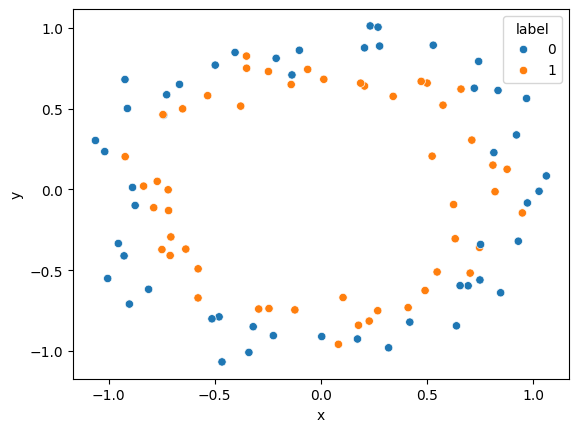

In [9]:
# Create the scatter plot
sns.scatterplot(data=df, x='x', y='y', hue='label')
plt.show()


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [11]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [12]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [13]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, verbose=0)

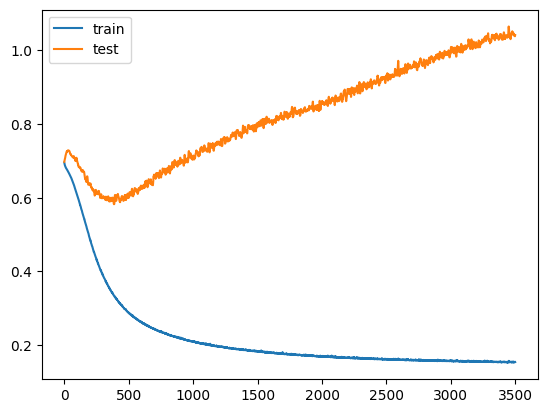

In [14]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


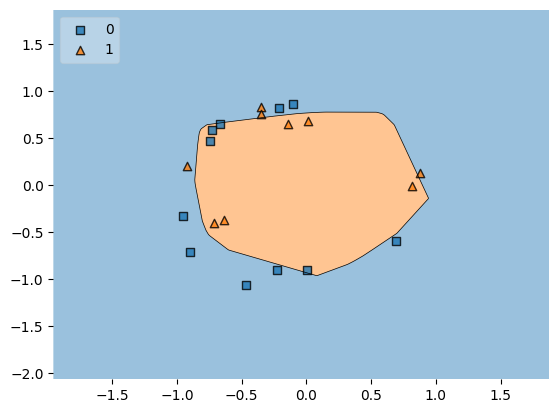

In [15]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

# Early Stopping

In [16]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [17]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [18]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [21]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5352 - loss: 0.6828 - val_accuracy: 0.4500 - val_loss: 0.7182
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5547 - loss: 0.6780 - val_accuracy: 0.4500 - val_loss: 0.7178
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5492 - loss: 0.6793 - val_accuracy: 0.4500 - val_loss: 0.7181
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6117 - loss: 0.6715 - val_accuracy: 0.4000 - val_loss: 0.7190
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6062 - loss: 0.6718 - val_accuracy: 0.3500 - val_loss: 0.7197
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6203 - loss: 0.6716 - val_accuracy: 0.3500 - val_loss: 0.7195
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6047 - loss: 0.6663 - val_accuracy: 0.3500 - val_loss: 0.7190
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6086 - loss: 0.6749 - val_accuracy: 0.3000 - v

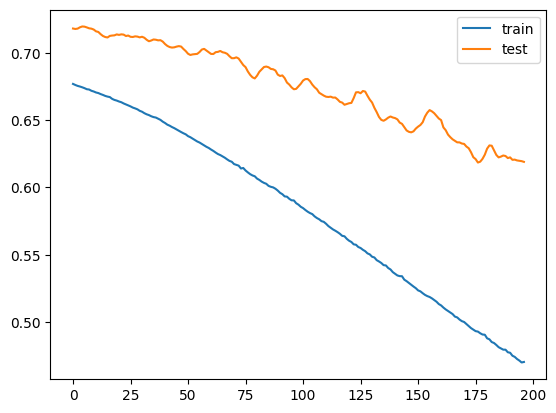

In [22]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


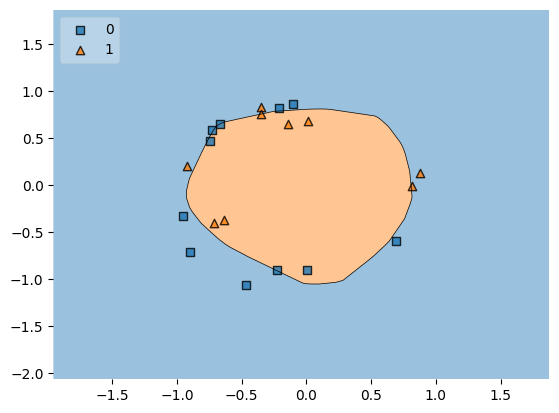

In [23]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

---